In [1]:
#Cell 1: Imports

import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_recall_fscore_support
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")
print(f"TensorFlow version: {tf.__version__}")

Imports successful.
TensorFlow version: 2.19.0


In [2]:
#Cell 2: Configuration Parameters

GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # Reduced batch size for better generalization in scratch training
NUM_CLASSES = 4
EPOCHS = 100

# Learning rate for training from scratch (usually lower than transfer learning)
LEARNING_RATE = 1e-5

SEED = 42
BEST_MODEL_SAVE_PATH = '/content/drive/MyDrive/vgg19_scratch_best.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")
print(f"Mode: TRAINING FROM SCRATCH (Random Initialization)")

Configuration parameters set.
Mode: TRAINING FROM SCRATCH (Random Initialization)


In [3]:
#Cell 3: Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

if not os.path.exists(DATA_DIR):
    print(f"Copying {GDRIVE_ZIP_PATH} to local storage...")
    shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

    if os.path.exists(LOCAL_UNZIP_DIR):
        shutil.rmtree(LOCAL_UNZIP_DIR)
    os.makedirs(LOCAL_UNZIP_DIR)

    print(f"Extracting {LOCAL_ZIP_PATH}...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
        z.extractall(LOCAL_UNZIP_DIR)
else:
    print("Data already extracted.")

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset ready.")

Mounted at /content/drive
Copying /content/drive/MyDrive/AD_Dataset_compressed.zip to local storage...
Extracting /content/Data.zip...
Dataset ready.


In [4]:
#Cell 4: Load Dataset & Split (80/10/10)

full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes found:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

# Ensure at least 1 batch for val and test
if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"\nDataset splits:")
print(f"Total batches: {total_batches}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")

Found 86437 files belonging to 4 classes.
Classes found: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']

Dataset splits:
Total batches: 1351
Training batches: 1080
Validation batches: 135
Test batches: 136


In [5]:
#Cell 5: Data Augmentation Pipeline

# Enhanced augmentation for training from scratch
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

def add_gaussian_noise(image, label):
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    noisy_image = tf.clip_by_value(image + noise, 0.0, 1.0)
    return noisy_image, label

# Apply augmentation
train_dataset_aug = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y),
                                       num_parallel_calls=AUTOTUNE)
train_dataset_aug = train_dataset_aug.map(add_gaussian_noise, num_parallel_calls=AUTOTUNE)

# Cache and prefetch
train_dataset_aug = train_dataset_aug.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Augmentation pipeline configured.")

Augmentation pipeline configured.


In [6]:
#Cell 6: Define Improved Focal Loss Function

def focal_loss_fn(alpha=0.75, gamma=3.0):
    """
    Improved Focal Loss for handling class imbalance without explicit class weights.
    alpha: increased to 0.75 to help minority classes
    gamma: increased to 3.0 to heavily penalize easy examples (majority class)
    """
    def focal_loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
    return focal_loss

print("Improved Focal Loss function defined (alpha=0.75, gamma=3.0)")

Improved Focal Loss function defined (alpha=0.75, gamma=3.0)


In [7]:
#Cell 7: Build VGG19 From Scratch (Architecture)

print("Building VGG19 with Random Initialization...")

# 1. Base Model with RANDOM weights
base_model = VGG19(
    weights=None,  # <--- No ImageNet weights
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = True # Train everything

# 2. Build Custom Head with Batch Normalization
# Batch Normalization is critical when training deep networks from scratch
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.vgg19.preprocess_input(x)

x = base_model(x, training=True)
x = GlobalAveragePooling2D()(x)

# Simplified head to prevent overfitting on small data
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x) # Added for stability
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x) # Added for stability
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x) # Added for stability
x = Dropout(0.2)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

model.summary()

Building VGG19 with Random Initialization...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        516 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 20,455,364 (78.03 MB)

 Trainable params: 20,453,572 (78.02 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [8]:
#Cell 8: Train From Scratch

# Custom callback to monitor class predictions
# This prints the distribution of predictions every epoch to detect collapse
class ClassDistributionCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 5 == 0: # Check every 5 epochs
            val_pred = self.model.predict(val_dataset, verbose=0)
            val_classes = np.argmax(val_pred, axis=1)
            unique, counts = np.unique(val_classes, return_counts=True)
            dist = dict(zip(unique, counts))
            print(f"\n[Epoch {epoch}] Val Class Dist: {dist} (Target: Mixed)")

optimizer = Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=focal_loss_fn(alpha=0.75, gamma=3.0), # Using improved focal loss
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    BEST_MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20, # Higher patience for scratch training
    restore_best_weights=True,
    verbose=1
)

print(f"Starting training from scratch for {EPOCHS} epochs...")
print("Using Focal Loss ONLY (No class weights) to prevent instability.")

history_scratch = model.fit(
    train_dataset_aug,
    epochs=EPOCHS,
    validation_data=val_dataset,
    # class_weight=class_weight_dict,  <-- REMOVED to prevent conflict with Focal Loss
    callbacks=[checkpoint, lr_scheduler, early_stop, ClassDistributionCallback()],
    verbose=1
)

print("\nTraining complete!")

Starting training from scratch for 100 epochs...
Using Focal Loss ONLY (No class weights) to prevent instability.
Epoch 1/100
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2656 - loss: 0.9636
Epoch 1: val_loss improved from inf to 1.05843, saving model to /content/drive/MyDrive/vgg19_scratch_best.keras

[Epoch 0] Val Class Dist: {np.int64(1): np.int64(6997), np.int64(3): np.int64(1643)} (Target: Mixed)
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 205s 172ms/step - accuracy: 0.2657 - loss: 0.9636 - val_accuracy: 0.0492 - val_loss: 1.0584 - learning_rate: 1.0000e-05
Epoch 2/100
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3050 - loss: 0.7508
Epoch 2: val_loss did not improve from 1.05843
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 144s 133ms/step - accuracy: 0.3051 - loss: 0.7507 - val_accuracy: 0.1647 - val_loss: 1.8386 - learning_rate: 1.0000e-05
Epoch 3/100
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4235 - loss: 0.5028
Epoch 3: val_loss did not improve from 1.05843
108

FINAL EVALUATION (VGG19 FROM SCRATCH)
Training Accuracy:   0.7790
Validation Accuracy: 0.7693
Test Accuracy:       0.7784

Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.0000    0.0000    0.0000       523
 Moderate Dementia     0.0000    0.0000    0.0000        54
      Non Demented     0.7784    1.0000    0.8754      6754
Very mild Dementia     0.0000    0.0000    0.0000      1346

          accuracy                         0.7784      8677
         macro avg     0.1946    0.2500    0.2188      8677
      weighted avg     0.6059    0.7784    0.6814      8677



MODEL: VGG19 TRAINED FROM SCRATCH (NO TRANSFER LEARNING)


Configuration:
- weights=None (Random Init)
- Improved Focal Loss (alpha=0.75, gamma=3.0)
- BatchNormalization added
- No Class Weights (Focal Loss handles imbalance)

Results:
- Training Accuracy:   0.7790
- Validation Accuracy: 0.7693
- Test Accuracy:       0.7784

Per-Class Performance:
                   

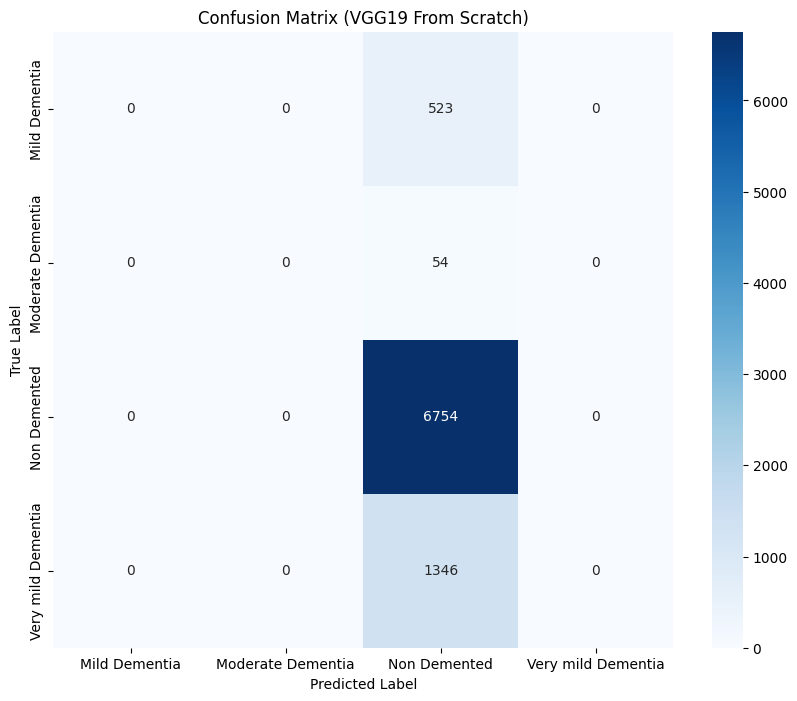

In [9]:
#Cell 9: Evaluation

print("=" * 80)
print("FINAL EVALUATION (VGG19 FROM SCRATCH)")
print("=" * 80)

# Load best model
best_model = tf.keras.models.load_model(
    BEST_MODEL_SAVE_PATH,
    custom_objects={'focal_loss': focal_loss_fn(alpha=0.75, gamma=3.0)}
)

# Evaluate
test_loss, test_acc = best_model.evaluate(test_dataset, verbose=0)
train_loss, train_acc = best_model.evaluate(train_dataset, verbose=0)
val_loss, val_acc = best_model.evaluate(val_dataset, verbose=0)

print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

# Predictions
y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)
y_pred_probs = best_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Find early stage index
early_stage_idx = None
for i, name in enumerate(class_names):
    if 'Very mild' in name or 'very mild' in name:
        early_stage_idx = i
        break

if early_stage_idx is not None:
    early_stage_recall = f"{recall[early_stage_idx]:.4f}"
else:
    early_stage_recall = "N/A"

# Save summary
summary_text = f"""

MODEL: VGG19 TRAINED FROM SCRATCH (NO TRANSFER LEARNING)


Configuration:
- weights=None (Random Init)
- Improved Focal Loss (alpha=0.75, gamma=3.0)
- BatchNormalization added
- No Class Weights (Focal Loss handles imbalance)

Results:
- Training Accuracy:   {train_acc:.4f}
- Validation Accuracy: {val_acc:.4f}
- Test Accuracy:       {test_acc:.4f}

Per-Class Performance:
{classification_report(y_true, y_pred, target_names=class_names, digits=4)}

Early Detection Focus:
- Very Mild Dementia Recall: {early_stage_recall}
"""

print(summary_text)

with open('vgg19_from_scratch_summary.txt', 'w') as f:
    f.write(summary_text)

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (VGG19 From Scratch)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()